In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

sns.set()
pd.set_option('display.max_columns', None)

# **DATA LOADING & INITIAL PREPROCESSING**

In [2]:
data = pd.read_csv("Final_airbnb_data.csv")
data["date"] = pd.to_datetime(data["date"], format="%d-%m-%Y")

print(f"Total rows: {len(data)}")
print(f"Unique listings: {data['listing_id'].nunique()}")
print(f"Date range: {data['date'].min()} to {data['date'].max()}")

# Create surcharges
data["surchages"] = data["cleaning_fee"] + data["extra_guest_fee"]

# Drop redundant columns
data = data.drop(columns=["cleaning_fee", "extra_guest_fee", "revenue",
                           "rate_avg", "booked_rate_avg", "native_revenue",
                           "min_nights_avg", "native_booked_rate_avg"])


Total rows: 12240
Unique listings: 1020
Date range: 2024-12-01 00:00:00 to 2025-11-01 00:00:00


# **HANDLE MISSING VALUES**

In [3]:
data["booking_lead_time_avg"] = data["booking_lead_time_avg"].fillna(
    data.groupby("City")["booking_lead_time_avg"].transform("median")
)
data["length_of_stay_avg"] = data["length_of_stay_avg"].fillna(
    data.groupby("City")["length_of_stay_avg"].transform("median")
)
data["guests"] = data["guests"].fillna(data.groupby("City")["guests"].transform("median"))
data["instant_book"] = data["instant_book"].fillna(False)
data["professional_management"] = data["professional_management"].fillna(False)
data["min_nights"] = data["min_nights"].fillna(data.groupby("City")["min_nights"].transform("median"))
data["rating_overall"] = data["rating_overall"].fillna(data.groupby("City")["rating_overall"].transform("median"))
data["surchages"] = data["surchages"].fillna(0)


# **ENCODE CATEGORICAL VARIABLES**

In [4]:
# One-hot encode City (no ordinal assumption)
city_dummies = pd.get_dummies(data["City"], prefix="city", drop_first=False).astype(int)
data = pd.concat([data.drop(columns=["City"]), city_dummies], axis=1)

data['cancellation_policy'] = data["cancellation_policy"].map({
    "Moderate": 0, "Flexible": 1, "Firm": 2, "Strict": 3, "Limited": 4
})

# Bin num_reviews
data['num_reviews_3bin'] = pd.qcut(data['num_reviews'], q=3, duplicates='drop')
data['num_reviews_3bin'] = data['num_reviews_3bin'].cat.codes
data = data.drop(columns=["num_reviews"])


# **HANDLE AMENITIES**

In [5]:
amenities_dummies = data['amenities'].str.get_dummies(sep=',')
amenity_freq = amenities_dummies.sum().sort_values(ascending=False)
amenity_share = amenity_freq / len(amenities_dummies)

# Select differentiating amenities (present in 10-40% of listings)
# These distinguish premium listings, unlike near-universal baseline amenities
selected_amenities = amenity_share[(amenity_share >= 0.10) & (amenity_share <= 0.40)].index
amenities_selected = amenities_dummies[selected_amenities]

amenities_selected = amenities_selected.astype(int)
print(f"Selected {len(selected_amenities)} differentiating amenities (10-40% prevalence) ✓")

data = pd.concat([data.drop(columns=['amenities']), amenities_selected], axis=1)

# Convert boolean columns
data["instant_book"] = data["instant_book"].astype(int)
data["professional_management"] = data["professional_management"].astype(int)
data["superhost"] = data["superhost"].astype(int)


Selected 36 differentiating amenities (10-40% prevalence) ✓


# **FEATURE ENGINEERING**

In [6]:
# Sort for time series
data = data.sort_values(['listing_id', 'date']).reset_index(drop=True)

# Temporal features
data['month'] = data['date'].dt.month

# Cyclical encoding
data['month_sin'] = np.sin(2 * np.pi * data['month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['month'] / 12)

# Lag features
data['price_lag1'] = data.groupby('listing_id')['native_rate_avg'].shift(1)
data['occupancy_lag1'] = data.groupby('listing_id')['occupancy'].shift(1)

# Original demand/pressure features
data["pressure_t"] = data["reserved_days"] / (data["vacant_days"] + 1)
data["occupancy_change"] = data.groupby("listing_id")["occupancy"].diff(1)
data["urgency"] = np.where(data["reserved_days"] > 0,
                           1 / (data["booking_lead_time_avg"] + 1), 0)

# Reconstruct city label from one-hot dummies for grouping
city_cols = [c for c in data.columns if c.startswith('city_')]
data['_city_label'] = (data[city_cols] * list(range(len(city_cols)))).sum(axis=1).astype(int)

# ── Leave-one-out city market stats ──
# Exclude the current listing when computing city averages so the
# feature does not encode the listing's own price (which drives the target)
city_sum_price = data.groupby(['_city_label', 'date'])['native_rate_avg'].transform('sum')
city_sum_occ   = data.groupby(['_city_label', 'date'])['occupancy'].transform('sum')
city_count     = data.groupby(['_city_label', 'date'])['native_rate_avg'].transform('count')

data['city_price_mean']    = (city_sum_price - data['native_rate_avg']) / (city_count - 1)
data['city_occupancy_mean'] = (city_sum_occ  - data['occupancy'])       / (city_count - 1)

# Median: leave-one-out is expensive to compute exactly;
# use full-group median but never ratio it against the current listing's own price
data['city_price_median'] = data.groupby(['_city_label', 'date'])['native_rate_avg'].transform('median')

data = data.drop(columns=['_city_label'])

# price_vs_city_mean: last month's price vs this month's leave-one-out city mean
# Neither side contains the current listing's current price — clean
data['price_vs_city_mean'] = data['price_lag1'] / (data['city_price_mean'] + 1)

# Occupancy relative to city (leave-one-out)
data['occupancy_vs_city_mean'] = data['occupancy_lag1'] / (data['city_occupancy_mean'] + 1e-6)

# Trust-weighted quality score
data['quality_score'] = data['rating_overall'] * np.log1p(data['num_reviews_3bin'] + 1)

# Guest type proxy
data['guest_type_proxy'] = data['length_of_stay_avg'] / (data['booking_lead_time_avg'] + 1)


# **CREATE TARGET VARIABLE**

In [7]:
# Target: city-relative price tier (Low=0 / Medium=1 / High=2)
# Binned within each city-month group so tiers are always relative to local market

city_cols = [c for c in data.columns if c.startswith('city_')]
data['_city_label'] = (data[city_cols] * list(range(len(city_cols)))).sum(axis=1).astype(int)

def rank_based_tier(x):
    pct = x.rank(pct=True)
    return pd.cut(
        pct,
        bins=[0, 0.333, 0.667, 1.0],
        labels=[0, 1, 2],
        include_lowest=True
    ).astype(int)

data['price_tier'] = data.groupby(['_city_label', 'date'])['native_rate_avg'].transform(rank_based_tier)
data = data.drop(columns=['_city_label'])

print("\nTarget Distribution (0=Low, 1=Medium, 2=High):")
print(data['price_tier'].value_counts().sort_index())



Target Distribution (0=Low, 1=Medium, 2=High):
price_tier
0    1474
1    4007
2    6759
Name: count, dtype: int64


In [8]:
data

,listing_id,date,vacant_days,reserved_days,occupancy,booking_lead_time_avg,length_of_stay_avg,native_rate_avg,superhost,latitude,longitude,guests,instant_book,professional_management,min_nights,cancellation_policy,rating_overall,surchages,city_Bangalore,city_Chennai,city_Delhi,city_Mumbai,num_reviews_3bin,Smoking allowed,Body soap,Dining table,Dryer,Heating,Cleaning before checkout,Drying rack for clothing,Cable TV,Room-darkening shades,Cleaning products,Toaster,Freezer,Bathtub,Coffee maker,Backyard,Shower gel,Oven,Single level home,Laundromat nearby,Smoke alarm,Breakfast,Pets allowed,Books and reading material,Coffee,Blender,Wine glasses,Window guards,Carbon monoxide alarm,Rice maker,Conditioner,Outdoor furniture,Crib,Bidet,Safe,Mini fridge,Children’s books and toys,month,month_sin,month_cos,price_lag1,occupancy_lag1,pressure_t,occupancy_change,urgency,city_price_mean,city_occupancy_mean,city_price_median,price_vs_city_mean,occupancy_vs_city_mean,quality_score,guest_type_proxy,price_tier
0,71164,2024-12-01,27,4,0.129,18.0,2.0,3230,0,28.5666,77.2072,3.0,0,0,1.0,0,4.73,8.0,0,0,1,0,2,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,1,1,0,12,-2.449294e-16,1.000000e+00,NaN,NaN,0.142857,NaN,0.052632,4511.211806,0.426521,3467.0,NaN,NaN,6.559180,0.105263,0
1,71164,2025-01-01,28,3,0.097,1.0,3.0,4014,0,28.5666,77.2072,3.0,0,0,1.0,0,4.73,8.0,0,0,1,0,2,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,1,1,0,1,5.000000e-01,8.660254e-01,3230.0,0.129,0.103448,-0.032,0.500000,4595.381944,0.376451,3567.0,0.702727,0.342673,6.559180,1.500000,1
2,71164,2025-02-01,28,0,0.000,13.0,3.0,4086,0,28.5666,77.2072,3.0,0,0,1.0,0,4.73,8.0,0,0,1,0,2,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,1,1,0,2,8.660254e-01,5.000000e-01,4014.0,0.097,0.000000,-0.097,0.000000,4555.409722,0.444302,3636.0,0.880957,0.218319,6.559180,0.214286,0
3,71164,2025-03-01,25,6,0.194,4.0,3.0,3980,0,28.5666,77.2072,3.0,0,0,1.0,0,4.73,8.0,0,0,1,0,2,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,1,1,0,3,1.000000e+00,6.123234e-17,4086.0,0.000,0.230769,0.194,0.200000,4541.777778,0.386865,3543.0,0.899450,0.000000,6.559180,0.600000,2
4,71164,2025-04-01,30,0,0.000,13.0,3.0,3930,0,28.5666,77.2072,3.0,0,0,1.0,0,4.73,8.0,0,0,1,0,2,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,1,1,0,0,1,1,0,4,8.660254e-01,-5.000000e-01,3980.0,0.194,0.000000,-0.194,0.000000,4331.670139,0.247931,3407.0,0.918602,0.782474,6.559180,0.214286,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12235,42661301,2025-07-01,4,27,0.871,101.0,10.0,5297,1,13.0535,80.2596,4.0,0,0,2.0,0,4.80,0.0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7,-5.000000e-01,-8.660254e-01,5639.0,0.433,5.400000,0.438,0.009804,4088.253012,0.287259,2867.0,1.378980,1.507345,3.328125,0.098039,2
12236,42661301,2025-08-01,31,0,0.000,11.0,3.0,5288,1,13.0535,80.2596,4.0,0,0,2.0,0,4.80,0.0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,-8.660254e-01,-5.000000e-01,5297.0,0.871,0.000000,-0.871,0.000000,4085.222892,0.203488,2849.0,1.296307,4.280331,3.328125,0.250000,2
12237,42661301,2025-09-01,30,0,0.000,11.0,3.0,4946,1,13.0535,80.2596,4.0,0,0,2.0,0,4.80,0.0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,-1.000000e+00,-1.836970e-16,5288.0,0.000,0.000000,0.000,0.000000,4138.897590,0.145771,2824.0,1.277326,0.000000,3.328125,0.250000,2
12238,42661301,2025-10-01,28,3,0.097,1.0,3.0,5879,1,13.0535,80.2596,4.0,0,0,2.0,0,4.80,0.0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,-8.660254e-01,5.000000e-01,4946.0,0.000,0.103448,0.097,0.500000,4183.379518,0.127102,2884.0,1.182015,0.000000,3.328

# **DROP ROWS WITH MISSING TARGET/LAG FEATURES**

In [9]:
# Drop rows where lag features are missing (first month per listing)
data = data.dropna(subset=['price_lag1', 'price_tier'])

# Remove columns that would cause leakage or are not features
drop_cols = ['listing_id', 'date', 'price_tier',
             'native_rate_avg',
             'vacant_days', 'reserved_days', 'occupancy']

feature_cols = [col for col in data.columns if col not in drop_cols]
data_clean = data[feature_cols + ['listing_id', 'date', 'price_tier']].copy()


# **TRAIN-TEST SPLIT**

In [10]:
cutoff_date = data_clean["date"].quantile(0.75)
train_data = data_clean[data_clean["date"] < cutoff_date]
test_data = data_clean[data_clean["date"] >= cutoff_date]

# Dynamically build feature list from available columns
exclude_cols = {"listing_id", "date", "price_tier"}
top_20_features = [col for col in data_clean.columns if col not in exclude_cols]

X_train = train_data[top_20_features]
y_train = train_data['price_tier']
X_test = test_data[top_20_features]
y_test = test_data['price_tier']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("\nTrain target distribution:")
print(y_train.value_counts().sort_index())
print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

# Verify all numeric
non_numeric = X_train.select_dtypes(exclude=['int64', 'float64', 'int32', 'float32']).columns
if len(non_numeric) > 0:
    print(f"Converting {len(non_numeric)} non-numeric columns...")
    for col in non_numeric:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")
    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)
else:
    print("All features numeric ✓")


Train: (8160, 68), Test: (3060, 68)

Train target distribution:
price_tier
0     997
1    2655
2    4508
Name: count, dtype: int64

Test target distribution:
price_tier
0     358
1    1019
2    1683
Name: count, dtype: int64
Converting 1 non-numeric columns...


# **TRAIN MODEL WITH BALANCED CLASS WEIGHTS**

In [11]:
# Compute balanced class weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, weights))

print("\nComputed Balanced Class Weights:")
for cls, weight in class_weights_dict.items():
    class_name = ['Low Price', 'Medium Price', 'High Price'][cls]
    print(f"  Class {cls} ({class_name}): {weight:.3f}")

from xgboost import XGBClassifier

sample_weights = y_train.map(class_weights_dict)

model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train, sample_weight=sample_weights)
model_name = "XGBoost"



Computed Balanced Class Weights:
  Class 0 (Low Price): 2.728
  Class 1 (Medium Price): 1.024
  Class 2 (High Price): 0.603


# **EVALUATE**

In [12]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Price', 'Medium Price', 'High Price']))


Accuracy: 0.4781
Macro F1: 0.4302
Weighted F1: 0.4994

Confusion Matrix:
[[139 195  24]
 [245 471 303]
 [265 565 853]]

Classification Report:
              precision    recall  f1-score   support

   Low Price       0.21      0.39      0.28       358
Medium Price       0.38      0.46      0.42      1019
  High Price       0.72      0.51      0.60      1683

    accuracy                           0.48      3060
   macro avg       0.44      0.45      0.43      3060
weighted avg       0.55      0.48      0.50      3060



# **FEATURE IMPORTANCE**


Top 20 Features:
              feature  importance
         city_Chennai    0.097106
   price_vs_city_mean    0.033063
           price_lag1    0.032575
       city_Bangalore    0.023807
            longitude    0.020437
Carbon monoxide alarm    0.016857
           city_Delhi    0.016788
              Heating    0.015615
    Outdoor furniture    0.014937
         instant_book    0.014792
                Bidet    0.014262
             latitude    0.014182
          Smoke alarm    0.013982
                 Crib    0.013814
                 Safe    0.013533
            month_cos    0.013511
     occupancy_change    0.013447
  city_occupancy_mean    0.013440
           min_nights    0.013421
        quality_score    0.013420


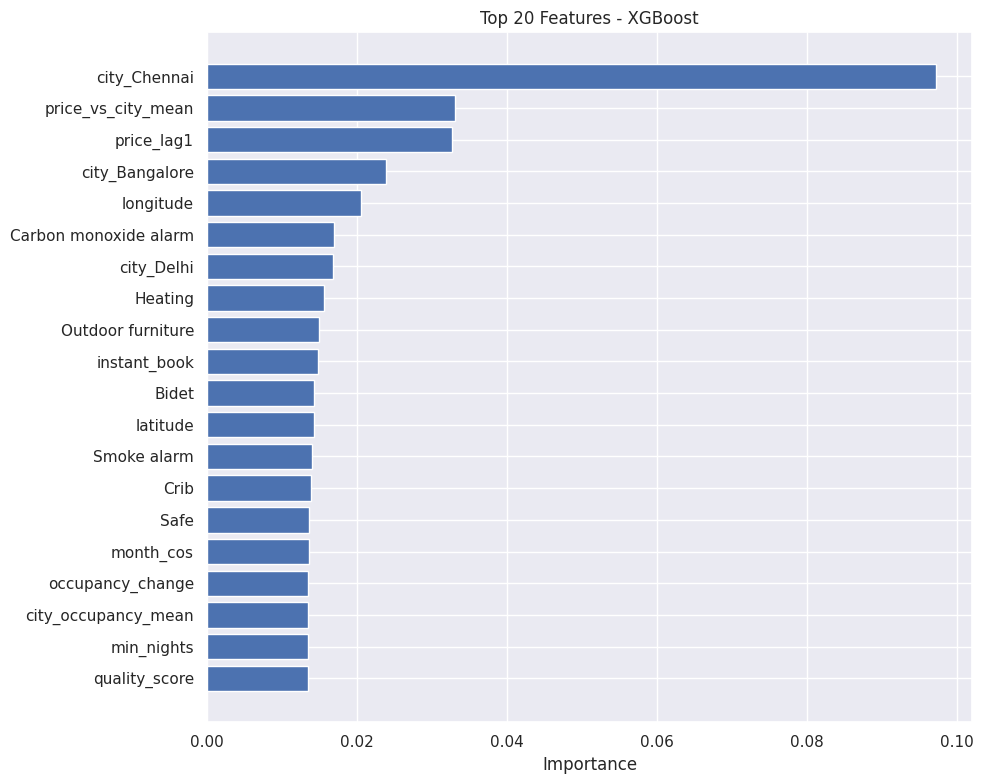

In [13]:
if hasattr(model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\nTop 20 Features:")
    print(feature_importance.head(20).to_string(index=False))

    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(20)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()

# **SHAP ANALYSIS**

In [14]:
!pip install shap

In [15]:
try:
    import shap

    sample_size = min(500, len(X_train))
    X_sample = X_train.sample(sample_size, random_state=42)

    print(f"\nComputing SHAP values for {sample_size} samples...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    print("SHAP values computed!")

    # *** FIX: INDEX BY CLASS FOR MULTICLASS ***
    class_names = ['Low Price', 'Medium Price', 'High Price']

    for i, class_name in enumerate(class_names):
        plt.figure(figsize=(10, 8))

        if isinstance(shap_values, list):
            shap.summary_plot(
                shap_values[i],  # ← INDEX THE CLASS!
                X_sample,
                plot_type="bar",
                show=False,
                max_display=20
            )
        else:
            shap.summary_plot(
                shap_values[:, :, i],
                X_sample,
                plot_type="bar",
                show=False,
                max_display=20
            )

        plt.title(f'SHAP - {class_name}', fontsize=14, fontweight='bold')
        plt.tight_layout()

        filename = f'shap_class_{i}_{class_name.replace(" ", "_")}.png'
        plt.savefig(filename, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"  Saved: {filename}")

    print("\n✓ All numerical features should now be visible in SHAP!")

except ImportError:
    print("\nSHAP not installed. Install with: pip install shap")
    print("\nCorrect usage for multiclass:")
    print("shap_values = explainer.shap_values(X_train)")
    print("shap.summary_plot(shap_values[0], X_train, plot_type='bar')  # Class 0")
    print("shap.summary_plot(shap_values[1], X_train, plot_type='bar')  # Class 1")
    print("shap.summary_plot(shap_values[2], X_train, plot_type='bar')  # Class 2")



Computing SHAP values for 500 samples...
SHAP values computed!
  Saved: shap_class_0_Low_Price.png
  Saved: shap_class_1_Medium_Price.png
  Saved: shap_class_2_High_Price.png

✓ All numerical features should now be visible in SHAP!


In [16]:
 # ============================================================================
results = pd.DataFrame({
    'listing_id': test_data['listing_id'].values,
    'date': test_data['date'].values,
    'actual': y_test.values,
    'predicted': y_pred
})
results.to_csv('predictions.csv', index=False)
print("\nPredictions saved: predictions.csv")



Predictions saved: predictions.csv


In [17]:
top_20_features = feature_importance.head(20)

In [18]:
top_20_features["feature"].to_list()

['city_Chennai',
 'price_vs_city_mean',
 'price_lag1',
 'city_Bangalore',
 'longitude',
 'Carbon monoxide alarm',
 'city_Delhi',
 'Heating',
 'Outdoor furniture',
 'instant_book',
 'Bidet',
 'latitude',
 'Smoke alarm',
 'Crib',
 'Safe',
 'month_cos',
 'occupancy_change',
 'city_occupancy_mean',
 'min_nights',
 'quality_score']